# BÁO CÁO PHÂN TÍCH HIỆU NĂNG VÀ ĐỘ ỔN ĐỊNH CỦA CÁC THUẬT TOÁN GIẢI HỆ PHƯƠNG TRÌNH TUYẾN TÍNH

Báo cáo này thực hiện so sánh ba phương pháp:

1. **Gaussian Elimination**: Phương pháp trực tiếp.
2. **SVD Decomposition**: Phương pháp dựa trên phân tích ma trận.
3. **Gauss-Seidel**: Phương pháp lặp.

In [12]:
import os

# Import benchmark using absolute package path to avoid relative-import errors
from part3.benchmark import benchmark, plot_results, stability_analysis


### 1. Thực nghiệm Hiệu năng (Benchmarking)

Chúng ta sẽ đo thời gian thực thi của từng phương pháp khi kích thước ma trận $n$ tăng dần.

In [10]:
sizes = [10, 20]

In [11]:
df_benchmark = benchmark(sizes)
display(df_benchmark.pivot(index="n", columns="Method", values="Time"))

Generated SPD matrix of size 10 in 0.0013 seconds.
Generated SPD matrix of size 20 in 0.0033 seconds.


Method,Gauss,Gauss-Seidel,SVD
n,,,
10,0.001429,0.000665,0.209068
20,0.002666,0.003064,1.458099


In [7]:
display(df_benchmark.pivot(index="n", columns="Method", values="Error time"))

Method,Gauss,Gauss-Seidel,SVD
n,,,
80,0.002996,0.001,0.001962


### 2. Biểu đồ Thời gian thực thi (Log-Log Plot)

Sử dụng biểu đồ Log-Log để kiểm chứng độ phức tạp thuật toán $O(n^3)$.

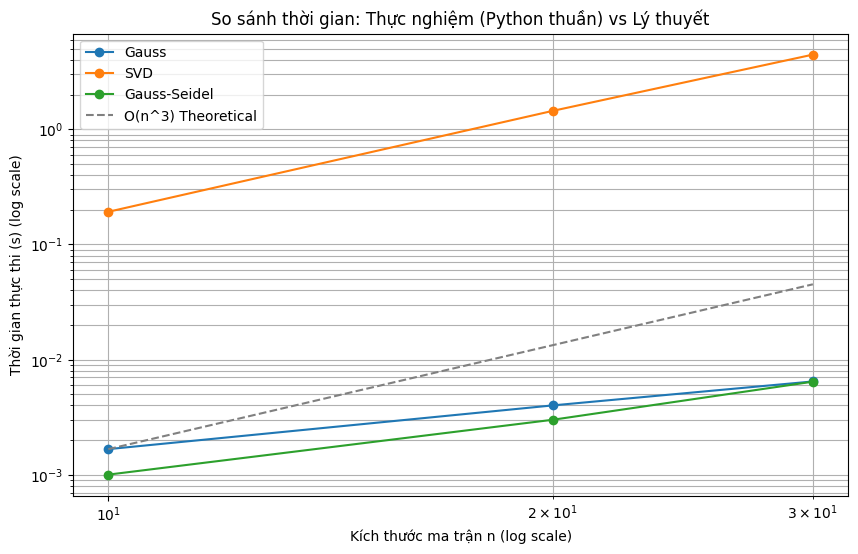

In [10]:
plot_results(df_benchmark, sizes)

### 3. Phân tích Độ ổn định (Stability Analysis)

Chúng ta so sánh sai số khi giải hệ phương trình với **Ma trận Hilbert** (xấu) và **Ma trận SPD** (tốt). Ma trận Hilbert có các hàng gần như phụ thuộc tuyến tính, khiến các sai số làm tròn nhỏ nhất cũng bị phóng đại.

In [12]:
df_analysis = stability_analysis(5)
display(df_analysis)


Stability Analysis (n=5):


,Method,Error Hilbert,Error SPD
0,Gauss,1.681451e-14,1.110223e-16
1,SVD,3.067028e-01,3.284593e-04
